In [77]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)
from laboneq.analysis.fitting import oscillatory

print(laboneq.__version__)

2.51.0


In [78]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.26 08:20:36.443] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.26 08:20:36.455] INFO    VERSION: laboneq 2.51.0
[2025.08.26 08:20:36.457] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.26 08:20:36.461] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.26 08:20:36.466] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.26 08:20:36.471] INFO    Configuring the device setup
[2025.08.26 08:20:36.480] INFO    The device setup is configured


In [79]:
res_lo_freq = 7.2e9
qb_lo_freq = 3.2e9
qubit_label = "Q2"  # change if needed
# qb_freq = 3.10268e9 #Q1
qb_freq = 3.19586e9 #Q2
# qb_freq = 3.19190e9 #Q3
# qb_freq = 3.37406e9 #Q4
# qb_freq =3.37316e9 #Q5
# qb_freq = 3.3990e9 #Q6

# res_freq = 7.14886e9 #Q1
res_freq = 7.18128e9 #Q2
# res_freq = 7.20643e9 #Q3
# res_freq = 7.23027e9 #Q4
# res_freq = 7.26203e9 #Q5
# res_freq = 7.29047e9 #Q6
integration_time = 5e-6

time_start = 1e-8
time_stop = 5e-6
length_num = 201

ro_pulse_amp = 0.1
ro_pulse_length = 5e-6

# drive_pulse_amp = 0.562 #Q1
drive_pulse_amp = 0.372 #Q2
# drive_pulse_amp = 0.199 #Q3
# drive_pulse_amp = 0.184 #Q4
# drive_pulse_amp = 0.263 #Q5
# drive_pulse_amp = 0.188 #Q6
drive_pulse_length = 1e-6 
drive_range = 5
num_averages = 11  # average number = 2^n, n_max = 17
measure_range = -20  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -30
acquire_amp = 0.9


In [80]:
# range of pulse amplitude scan
def create_rabi_length_sweep(time_start, time_stop, length_num, uid="rabi_length"):
    return LinearSweepParameter(uid="length", start=time_start, stop=time_stop, count=length_num)

In [81]:
# power spectral mode for better accuracy, cannot catch the phase diff, it deos not use IQ, better for amplitude
def length_rabi(length_sweep, drive_length, drive_amp, ro_length, ro_amp):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )
    readout_pulse = pulse_library.const(uid="readout_pulse", length=ro_length, amplitude=ro_amp)
    drive_pulse = pulse_library.const('drive_pulse',length=drive_length,amplitude=drive_amp, can_compress=True)
    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=pow(2, num_averages),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=length_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation"):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, length = length_sweep)
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.measure(
                    acquire_signal="acquire",
                    integration_length = integration_time,
                    handle="length_rabi",
                    reset_delay = 50e-6,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=250e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

In [82]:
# define pulses and create experiment
exp_rabi = length_rabi(create_rabi_length_sweep(time_start, time_stop, length_num), drive_pulse_length, drive_pulse_amp, ro_pulse_length, ro_pulse_amp)


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

In [83]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq-qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
exp_rabi.set_calibration(exp_calibration)

In [84]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi_length", compiled_rabi)

[2025.08.26 08:20:36.547] INFO    Starting LabOne Q Compiler run...
[2025.08.26 08:20:36.601] INFO    Schedule completed. [0.051 s]
[2025.08.26 08:20:36.796] INFO    Requested to compress pulse(s) drive_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.08.26 08:20:36.797] INFO    Requested to compress pulse(s) drive_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.08.26 08:20:37.291] INFO    Code generation completed for all AWGs. [0.690 s]
[2025.08.26 08:20:37.293] INFO    Completed compilation step 1 of 1. [0.743 s]
[2025.08.26 08:20:37.296] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.26 08:20:37.298] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.26 08:20:37.298] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.26 08:20:37.298] INFO      device_shfqc        0       1010   

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Rabi_length_2025-08-26-08-20-37.html

In [85]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")

# --- Make output folder + timestamp ---
outdir = "rabi_length_results"
os.makedirs(outdir, exist_ok=True)


[2025.08.26 08:20:38.528] INFO    Starting near-time execution...
[2025.08.26 08:20:38.624] INFO    Estimated RT execution time: 126.59 s.
[2025.08.26 08:22:45.280] INFO    Finished near-time execution.


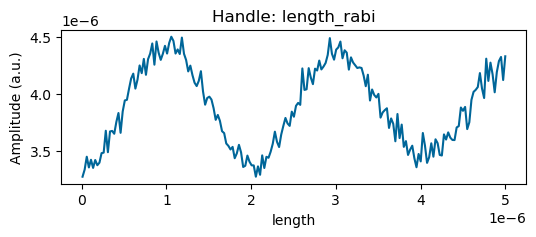

In [86]:
plot_results(rabi_results)

Saved figure to rabi_length_results\rabi_experiment_length_Q2_20250826T082245.png
Saved data to rabi_length_results\rabi_experiment_length_Q2_20250826T082245.csv


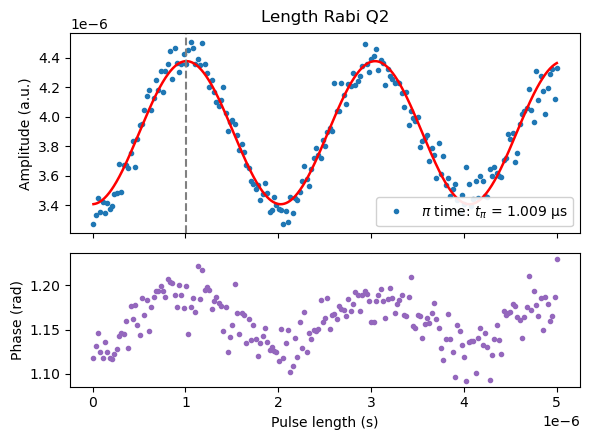

In [87]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# ---------- Get data (Length Rabi) ----------
rabi_res = rabi_results.get_data("length_rabi")        # complex IQ
L        = np.asarray(rabi_results.get_axis("length_rabi")[0], float)  # [s]

# Clean + sort
R = np.abs(rabi_res).astype(float)  # linear magnitude (a.u.)
m = np.isfinite(L) & np.isfinite(R)
L, R = L[m], R[m]
idx = np.argsort(L)
L, R = L[idx], R[idx]

# ---------- Cosine model WITH phase ----------
# R(L) = A * cos(2π f * L + φ) + C
def rabi_cosine_phase(L, A, f, phi, C):
    return A * np.cos(2*np.pi*f*L + phi) + C

# ---------- Initial guesses ----------
C_guess  = float(np.nanmean(R))
A_guess  = 0.5 * (float(np.nanmax(R)) - float(np.nanmin(R)))

# Frequency guess via FFT or fallback
R_detr = R - C_guess
if len(L) >= 3 and np.allclose(np.diff(L), np.diff(L)[0], rtol=1e-3, atol=0):
    dL = float(np.mean(np.diff(L)))
    freqs = np.fft.rfftfreq(len(L), d=dL)
    Yf = np.abs(np.fft.rfft(R_detr))
    if Yf.size > 1:
        f_guess = float(freqs[1 + int(np.nanargmax(Yf[1:]))])
    else:
        span = max(float(np.ptp(L)), 1e-9)
        f_guess = 1.0 / span
else:
    pk_tmp, _ = find_peaks(R_detr, distance=max(2, len(R)//20))
    if len(pk_tmp) >= 2:
        period_est = float(np.median(np.diff(L[pk_tmp])))
        f_guess = 1.0 / max(period_est, 1e-9)
    else:
        span = max(float(np.ptp(L)), 1e-9)
        f_guess = 1.0 / span

# Phase guess using a simple demod at f_guess
if np.isfinite(f_guess) and f_guess > 0:
    phi_guess = float(np.angle(np.sum(R_detr * np.exp(-1j*2*np.pi*f_guess*L))))
else:
    phi_guess = 0.0

p0 = [A_guess, f_guess, phi_guess, C_guess]
lower = [-np.inf, 0.0, -2*np.pi, -np.inf]  # A free, f>=0, -2π<=phi<=2π, C free
upper = [ np.inf,  np.inf,  2*np.pi,  np.inf]

# ---------- Fit (linear units) ----------
popt, pcov = curve_fit(
    rabi_cosine_phase, L, R,
    p0=p0, bounds=(lower, upper), maxfev=20000
)
A_fit, f_fit, phi_fit, C_fit = popt

# ---------- Derived / plotting ----------
L_plot = np.linspace(L.min(), L.max(), 5*len(L))
R_fit  = rabi_cosine_phase(L_plot, *popt)

# π-time from first fitted maximum (peak of fitted curve)
pk_fit, _ = find_peaks(R_fit, distance=max(2, len(R_fit)//20))
idx_pi = int(pk_fit[0]) if len(pk_fit) else int(np.argmax(R_fit))
t_pi_s  = float(L_plot[idx_pi])
t_pi_us = 1e6 * t_pi_s

# Phase (still plot raw phase of data, just not fitted)
phase_rad = np.angle(rabi_res)[m][idx]

# ---------- Plot ----------
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                        gridspec_kw={'height_ratios': [1.5, 1.0]})

axs[0].plot(L, R, 'o', ms=3, label="data")
axs[0].plot(L_plot, R_fit, '-r', lw=1.8, label="fit")
axs[0].axvline(t_pi_s, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Amplitude (a.u.)")
axs[0].legend([rf"$\pi$ time: $t_\pi$ = {t_pi_us:.3f} μs"],
              loc="lower right", framealpha=0.9)
axs[0].set_title(f"Length Rabi {qubit_label}", fontsize=12, pad=8)

axs[1].plot(L, phase_rad, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Pulse length (s)")
axs[1].set_ylabel("Phase (rad)")

plt.tight_layout()

# ---------- Save figure ----------
fig_path = os.path.join(outdir, f"rabi_experiment_length_{qubit_label}_{timestamp}.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

# ---------- Save data ----------
R_fit_on_L = rabi_cosine_phase(L, *popt)
df = pd.DataFrame({
    "PulseLength_s": L,
    "Magnitude_AU": R,
    "Fit_AU": R_fit_on_L,
    "Phase_rad": phase_rad,
    "A_fit": [A_fit]*len(L),
    "f_fit_Hz": [f_fit]*len(L),
    "phi_fit_rad": [phi_fit]*len(L),
    "C_fit": [C_fit]*len(L),
    "t_pi_s": [t_pi_s]*len(L),
})
csv_path = os.path.join(outdir, f"rabi_experiment_length_{qubit_label}_{timestamp}.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")

plt.show()
